In [ ]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings

import pandas as pd
import numpy as np

from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import StrMethodFormatter

import openturns as ot
import openturns.viewer as viewer

import io
from PIL import Image, ImageDraw, ImageFont

In [3]:
np.random.seed(42)
ot.Log.Show(ot.Log.NONE)
plt.rcParams['font.family'] = 'Arial'

In [8]:
from utils.copTools import *
from utils.asymmetry import *
from utils.c3 import *

# Changing Correlations Copula (c3) Fitting

# Overview

This notebook covers modelling the joint distribution of property damages sustained by weather events and their magnitudes using a special type of copulas first described by Bárdossy (Bárdossy, 2023). While the standard Gaussian copula is described on the unit box using a given correlation value between $[-1, 1]$, these copulas assume that the correlation changes throughout the copula. 

The scope of this project encompasses copulas that change their correlation as functions of the probability-integral-transformed predictor. Two cases are considered: one where the correlations change piecewise linearly, and one where they change polynomially. 

The functions used to measure the change in correlations are selected through optimisation of the indicator correlations. (BLA BLa BLA in paper)

In [293]:
ch = pd.read_csv('champaignIL.csv')
ck = pd.read_csv('cookIL.csv')

In [294]:
WIDTH = 174/25.4        # 174mm is the width of a single column in a single column, converted to inches for matplotlib
MAXHEIGHT = 234/25.4    # 234mm is the maximum height of a figure in a single column, converted to inches for matplotlib

# $k$-Nearest Neighbour Imputation

As with the standard copulas, $k$-nearest neighbour imputation is used to generate 2 kinds of datasets. The first kind retains only the complete datapoints and the second imputes missing magnitudes. As has been seen before, imputation of both missing magnitudes & property damages results in hallucinations that are not easily observable in the scope of this project

In [9]:
# Complete data

ckFull = ck.dropna()
chFull = ch.dropna()

In [10]:
# Magnitude only imputed

ckPropFull = ck.dropna(subset=['PropDmg'])
chPropFull = ch.dropna(subset=['PropDmg'])

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    chPropFullImp = impute(chPropFull[['Magnitude', 'PropDmg', 'PropDmg (adj. 2020)', 'PropDmgPerCapita (adj. 2020)']])
    ckPropFullImp = impute(ckPropFull[['Magnitude', 'PropDmg', 'PropDmg (adj. 2020)', 'PropDmgPerCapita (adj. 2020)']])

1 nearest neighbours will be used for imputation.
7 nearest neighbours will be used for imputation.


To easily map variables & fills to respective datasets, dictionaries are created

In [310]:
dataMap = {
    ('Cook IL', 'Complete Data'):               ckFull,
    ('Cook IL', 'Magnitude-Imputed Data'):      ckPropFullImp,
    ('Champaign IL', 'Complete Data'):          chFull,
    ('Champaign IL', 'Magnitude-Imputed Data'): chPropFullImp,
}

dmgMap = {
    'Property Damage (USD)':                      'PropDmg',
    'Property Damage (USD adj. 2020)':            'PropDmg (adj. 2020)',
    'Property Damage Per Capita (USD adj. 2020)': 'PropDmgPerCapita (adj. 2020)',
}

In [311]:
fills = ['Complete Data', 'Magnitude-Imputed Data']
dmgs = list(dmgMap.keys())

# Asymmetry

Before modelling c3 copulas, the *asymmetry* between variables is calculated to gain an understanding of how the variables are jointly distributed. Asymmetry gives a measure of how positively / negatively concordant the values are. In this section, the pairwise asymmetries between magnitude and property damages are recorded

Significant asymmetry values indicate the anticipation of changing correlation structure.

In [55]:
def asymmetryTable(dataMap, counties, fills, dmgs, dmgMap, asymmetry='concordance'):
    '''
    FUNCTION
    --------
    Builds a table of rank correlations and asymmetries for Magnitude vs damage variable pairs,
        across counties and fills, flagging statistically significant asymmetries

    PARAMETERS
    ----------
    dataMap:    Mapping from (county, fill) to DataFrame containing Magnitude and damage columns
                REQ: dict

    counties:   County names to iterate over
                REQ: list[str]

    fills:      Fill names to iterate over
                REQ: list[str]

    dmgs:       Damage variable keys to iterate over
                REQ: list[str]

    dmgMap:     Mapping from damage variable key to column name in dataMap DataFrames
                REQ: dict

    asymmetry:  Type of asymmetry to compute, either 'concordance' or 'direct'
                REQ: String

    RETURNS
    -------
    pandas.DataFrame
    table:      Rows of County, Fill, Variable pair, rank correlation, asymmetry, significance
    '''

    asymFns    = {'concordance': concAsyMatrix,  'direct': dirAsyMatrix}
    confIntFns = {'concordance': concAsyConfInt, 'direct': dirAsyConfInt}

    if asymmetry not in asymFns:
        raise ValueError(f"asymmetry must be one of {list(asymFns.keys())}")

    rows = []

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        for county in counties:
            for fill in fills:
                for var in dmgs:
                    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float).values
                    n    = data.shape[0]

                    rCorrMatrix             = rankCorrMatrix(data)
                    nRCorrMatrix            = normRankCorrMatrix(data)
                    asyMatrix               = asymFns[asymmetry](data)
                    lowerBounds, upperBounds = confIntFns[asymmetry](nRCorrMatrix, n)

                    rankCorr  = rCorrMatrix[0, 1]
                    asymValue = asyMatrix[0, 1]
                    sig       = (asymValue > upperBounds[0, 1]) or (asymValue < lowerBounds[0, 1])

                    rows += [{
                        'County':        county,
                        'Fill':          fill,
                        'Variable Pair': f"Magnitude & {var}",
                        'Rank Corr':     rankCorr,
                        'Asymmetry':     asymValue,
                        'Significant':   sig,
                    }]

    return pd.DataFrame(rows)

In [56]:
concAsyTable = asymmetryTable(dataMap, ['Cook IL', 'Champaign IL'], fills, dmgs, dmgMap)
concAsyTable

,County,Fill,Variable Pair,Rank Corr,Asymmetry,Significant
0,Cook IL,Complete data only,Magnitude & Property Damage (USD),0.280442,0.012350,False
1,Cook IL,Complete data only,Magnitude & Property Damage (USD adj. 2020),0.261310,0.013212,False
2,Cook IL,Complete data only,Magnitude & Property Damage Per Capita (USD ad...,0.246625,0.014453,False
3,Cook IL,Magnitude only imputed,Magnitude & Property Damage (USD),0.405362,-0.011792,False
4,Cook IL,Magnitude only imputed,Magnitude & Property Damage (USD adj. 2020),0.412987,-0.013594,True
5,Cook IL,Magnitude only imputed,Magnitude & Property Damage Per Capita (USD ad...,0.410043,-0.013928,True
6,Champaign IL,Complete data only,Magnitude & Property Damage (USD),0.443697,-0.003981,False
7,Champaign IL,Complete data only,Magnitude & Property Damage (USD adj. 2020),0.433467,0.004554,False
8,Champaign IL,Complete data only,Magnitude & Property Damage Per Capita (USD ad...,0.412459,0.007947,False
9,Champaign IL,Magnitude only imputed,Magnitude & Property Damage (USD),0.327928,0.002539,False


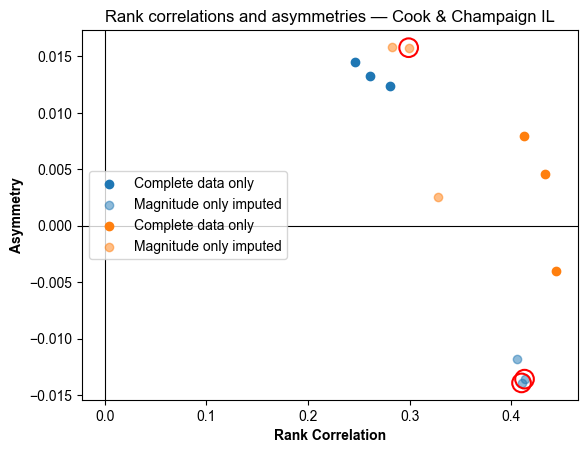

In [57]:
countyColors = {'Cook IL': 'tab:blue', 'Champaign IL': 'tab:orange'}

plt.figure()

for county, color in countyColors.items():
    countyTable = concAsyTable[concAsyTable['County'] == county]

    for fill, fillTable in countyTable.groupby('Fill'):
        alpha = 0.5 if fill.strip() == "Magnitude only imputed".strip() else 1.0
        label = f"{fill}"

        plt.scatter(fillTable['Rank Corr'], fillTable['Asymmetry'],
                    alpha=alpha, color=color, label=label)

        sigTable = fillTable[fillTable['Significant']]
        if len(sigTable):
            plt.scatter(sigTable['Rank Corr'], sigTable['Asymmetry'],
                        s=180, facecolors='none', edgecolors='red', linewidths=1.5)

plt.title("Rank correlations and asymmetries — Cook & Champaign IL")
plt.xlabel("Rank Correlation", fontweight='bold')
plt.ylabel("Asymmetry",        fontweight='bold')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.legend(loc='center left')
plt.show()

All the concordance asymmetries are insignificant, which means that the respective magnitudes and property damages are distributed without a significant skew. They are evenly distributed about the median point between the variables.

The only exception is the Champaign IL dataset where all the values were imputed. Here, a significant positive asymmetry is noted between the magnitude and property damage per capita in USD (adj. 2020) indicating a heavier upper tail.

# Piecewise Linear c3

Piecewiese linear strands have break points or 'knots' where the correlation values sharply change across the parameter threshold. Intermediate indicator correlations are linear interpolations of the end points of their respective segments.

## Fitting

In [198]:
strandMap = {}

In [ ]:
# Cook IL — Complete data only
county, fill = 'Cook IL', 'Complete Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    lineStrand, lineLow, lineUp = fitData(data, form='lines', max=3, nThresh=50)

    indicCorrs = indCorrs(data.values, np.linspace(0., 1., 101))
    obsCorrs = indCorrToGauss(indicCorrs, np.linspace(0., 1., 101))
    
    gaussCop = gaussCopula(data)
    rho = float(gaussCop.parameters[0][0])
    gaussLow, gaussUp = gaussianBand(rho, lineStrand.thresh, nSim=1000, nEns=1000, alpha=0.95)

    strandMap[(county, fill, var)] = {
        'obsCorrs': obsCorrs,
        'lineStrand': lineStrand,
        'lineLow': lineLow, 'lineUp': lineUp,
        'gaussLow': gaussLow, 'gaussUp': gaussUp,
    }

In [ ]:
# Cook IL — Magnitude only imputed
county, fill = 'Cook IL', 'Magnitude-Imputed Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    lineStrand, lineLow, lineUp = fitData(data, form='lines', max=3, nThresh=50)

    indicCorrs = indCorrs(data.values, np.linspace(0., 1., 101))
    obsCorrs = indCorrToGauss(indicCorrs, np.linspace(0., 1., 101))

    gaussCop = gaussCopula(data)
    rho = float(gaussCop.parameters[0][0])
    gaussLow, gaussUp = gaussianBand(rho, lineStrand.thresh, nSim=1000, nEns=1000, alpha=0.95)
    
    strandMap[(county, fill, var)] = {
        'obsCorrs': obsCorrs,
        'lineStrand': lineStrand,
        'lineLow': lineLow, 'lineUp': lineUp,
        'gaussLow': gaussLow, 'gaussUp': gaussUp,
    }

In [ ]:
# Champaign IL — Complete data only
county, fill = 'Champaign IL', 'Complete Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    lineStrand, lineLow, lineUp = fitData(data, form='lines', max=3, nThresh=50)

    indicCorrs = indCorrs(data.values, np.linspace(0., 1., 101))
    obsCorrs = indCorrToGauss(indicCorrs, np.linspace(0., 1., 101))

    gaussCop = gaussCopula(data)
    rho = float(gaussCop.parameters[0][0])
    gaussLow, gaussUp = gaussianBand(rho, lineStrand.thresh, nSim=1000, nEns=1000, alpha=0.95)
    
    strandMap[(county, fill, var)] = {
        'obsCorrs': obsCorrs,
        'lineStrand': lineStrand,
        'lineLow': lineLow, 'lineUp': lineUp,
        'gaussLow': gaussLow, 'gaussUp': gaussUp,
    }

In [ ]:
# Champaign IL — Magnitude only imputed
county, fill = 'Champaign IL', 'Magnitude-Imputed Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    lineStrand, lineLow, lineUp = fitData(data, form='lines', max=5, nThresh=50)
    
    indicCorrs = indCorrs(data.values, np.linspace(0., 1., 101))
    obsCorrs = indCorrToGauss(indicCorrs, np.linspace(0., 1., 101))

    gaussCop = gaussCopula(data)
    rho = float(gaussCop.parameters[0][0])
    gaussLow, gaussUp = gaussianBand(rho, lineStrand.thresh, nSim=1000, nEns=1000, alpha=0.95)

    strandMap[(county, fill, var)] = {
        'obsCorrs': obsCorrs,
        'lineStrand': lineStrand,
        'lineLow': lineLow, 'lineUp': lineUp,
        'gaussLow': gaussLow, 'gaussUp': gaussUp,
    }

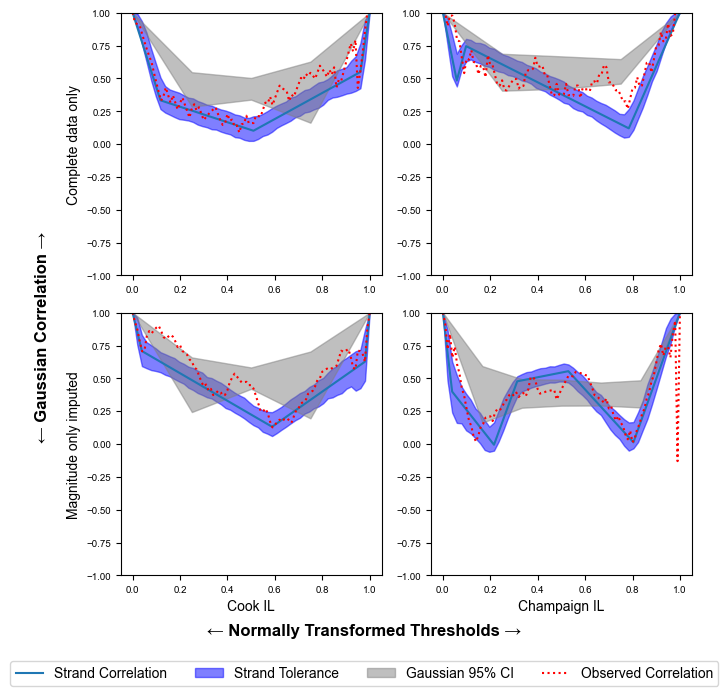

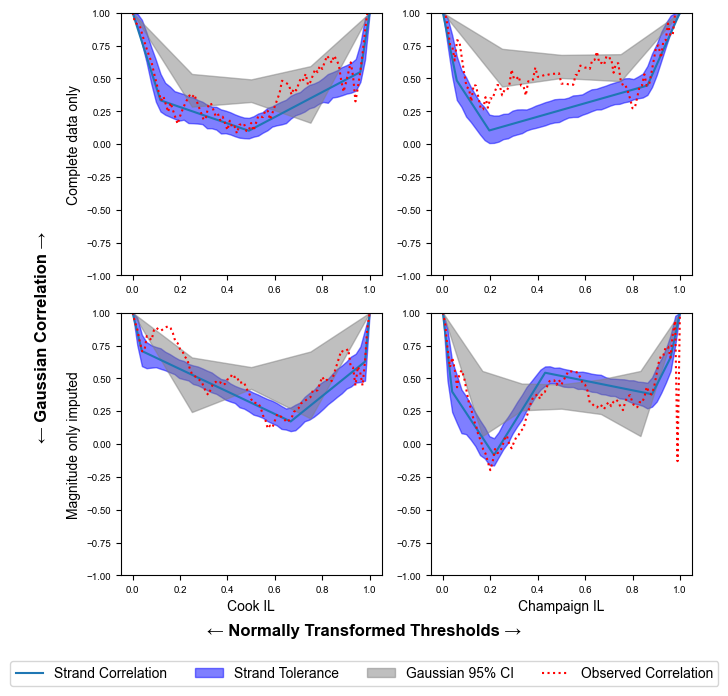

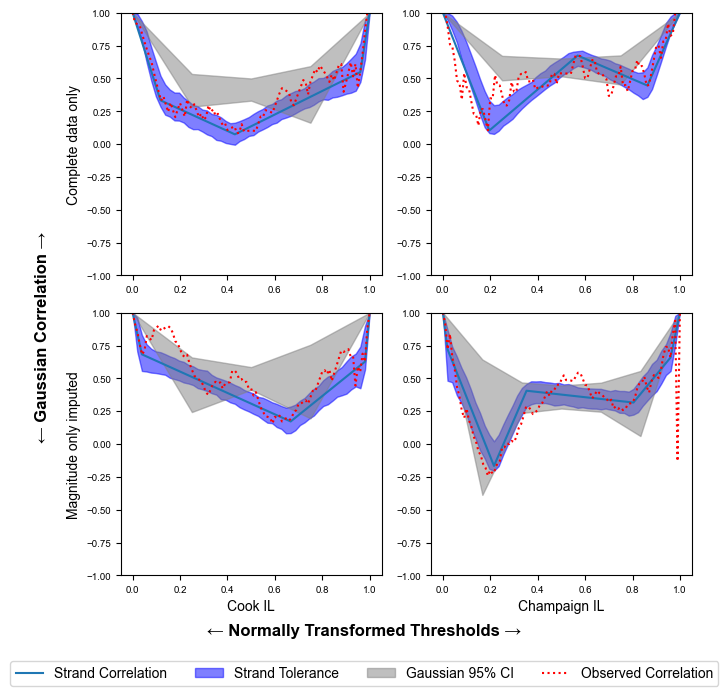

In [210]:
for var in dmgs:
    fig, axes = plt.subplots(len(fills), 2, figsize=(WIDTH, len(fills)*WIDTH/2))

    for i, fill in enumerate(fills):
        axes[i, 0].set_ylabel(fill, fontsize=10)
        for k, county in enumerate(['Cook IL', 'Champaign IL']):
            ax = axes[i, k]
            s = strandMap[(county, fill, var)]

            ax = plotStrand(s['lineStrand'], ax, label='Strand Correlation')
            ax = plotInterval(np.linspace(0., 1., len(s['lineLow'])), s['lineLow'], s['lineUp'], ax=ax, color='blue', alpha=0.5, label='Strand Tolerance')
            ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gray', alpha=0.5, label='Gaussian 95% CI')
            ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

            ax.set_ylim(-1, 1)
            ax.tick_params(labelsize=7)

    for k, county in enumerate(['Cook IL', 'Champaign IL']):
        axes[-1, k].set_xlabel(county, fontsize=10)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
    fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
    fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

### Image Saving

#### Main

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


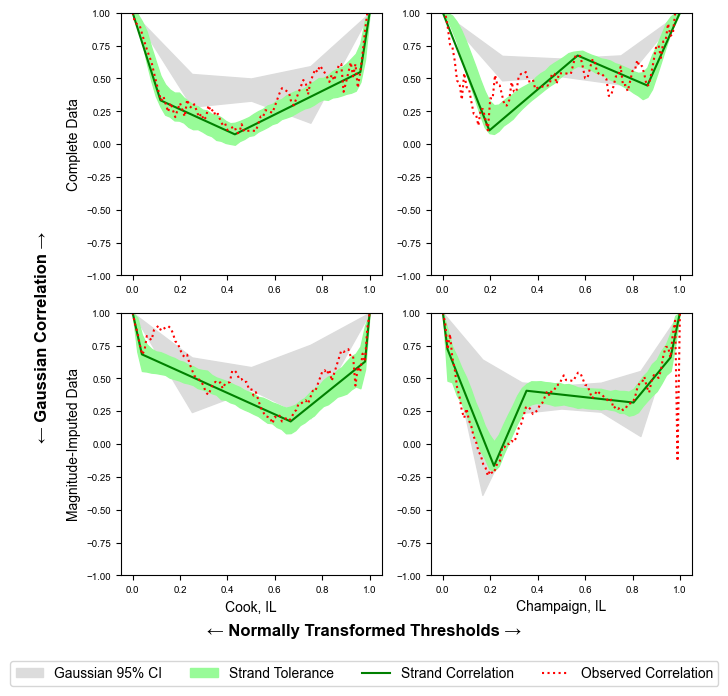

In [317]:
var = 'Property Damage Per Capita (USD adj. 2020)'

fig, axes = plt.subplots(len(fills), 2, figsize=(WIDTH, len(fills)*WIDTH/2))

for i, fill in enumerate(fills):
    axes[i, 0].set_ylabel(fill, fontsize=10)
    for k, county in enumerate(['Cook IL', 'Champaign IL']):
        ax = axes[i, k]
        s = strandMap[(county, fill, var)]

        ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gainsboro', label='Gaussian 95% CI')

        ax = plotInterval(np.linspace(0., 1., len(s['lineLow'])), s['lineLow'], s['lineUp'], ax=ax, color='palegreen', label='Strand Tolerance')
        ax = plotStrand(s['lineStrand'], ax, label='Strand Correlation', color='green')
        ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

        ax.set_ylim(-1, 1)
        ax.tick_params(labelsize=7)

for k, county in enumerate(['Cook, IL', 'Champaign, IL']):
    axes[-1, k].set_xlabel(county, fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'Fig9.eps', format='eps', bbox_inches='tight')
plt.show()

#### Appendix

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


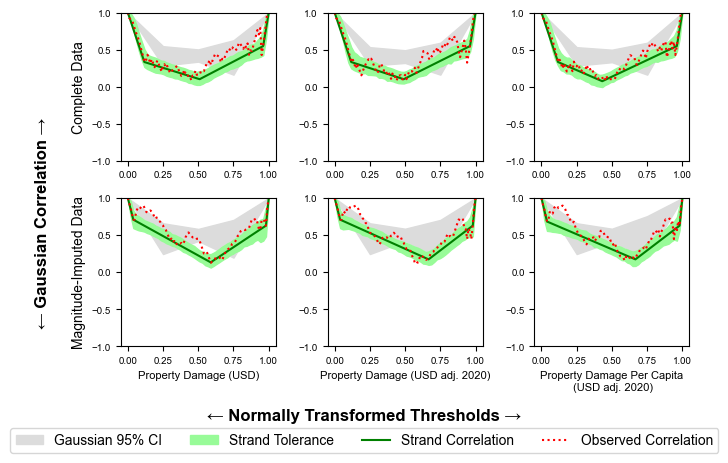

In [348]:
county = 'Cook IL'
fig, axes = plt.subplots(len(fills), len(dmgs), figsize=(WIDTH, len(fills)*WIDTH/len(dmgs)))

for i, fill in enumerate(fills):
    axes[i, 0].set_ylabel(fill, fontsize=10)
    for k, var in enumerate(dmgs):
        ax = axes[i, k]
        s = strandMap[(county, fill, var)]

        ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gainsboro', label='Gaussian 95% CI')
        ax = plotInterval(np.linspace(0., 1., len(s['lineLow'])), s['lineLow'], s['lineUp'], ax=ax, color='palegreen', label='Strand Tolerance')
        ax = plotStrand(s['lineStrand'], ax, label='Strand Correlation', color='green')
        ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

        ax.set_ylim(-1, 1)
        ax.tick_params(labelsize=7)

# Set column x-labels once, outside the fill loop, on the bottom row only
for k, var in enumerate(dmgs):
    if 'Per Capita' in var:
        label = var.replace('Per Capita', 'Per Capita\n')
    else:
        label = var
    axes[-1, k].set_xlabel(label, fontsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'Fig15.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


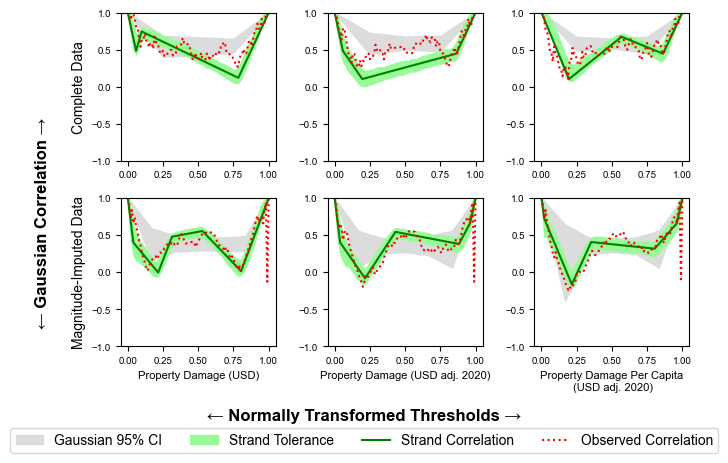

In [349]:
county = 'Champaign IL'
fig, axes = plt.subplots(len(fills), len(dmgs), figsize=(WIDTH, len(fills)*WIDTH/len(dmgs)))

for i, fill in enumerate(fills):
    axes[i, 0].set_ylabel(fill, fontsize=10)
    for k, var in enumerate(dmgs):
        ax = axes[i, k]
        s = strandMap[(county, fill, var)]

        ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gainsboro', label='Gaussian 95% CI')
        ax = plotInterval(np.linspace(0., 1., len(s['lineLow'])), s['lineLow'], s['lineUp'], ax=ax, color='palegreen', label='Strand Tolerance')
        ax = plotStrand(s['lineStrand'], ax, label='Strand Correlation', color='green')
        ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

        ax.set_ylim(-1, 1)
        ax.tick_params(labelsize=7)

# Set column x-labels once, outside the fill loop, on the bottom row only
for k, var in enumerate(dmgs):
    if 'Per Capita' in var:
        label = var.replace('Per Capita', 'Per Capita\n')
    else:
        label = var
    axes[-1, k].set_xlabel(label, fontsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'Fig16.eps', format='eps', bbox_inches='tight')
plt.show()

## Simulation

### All Simulations

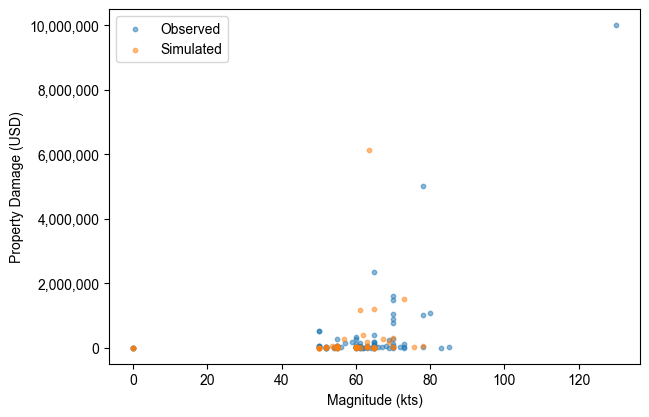

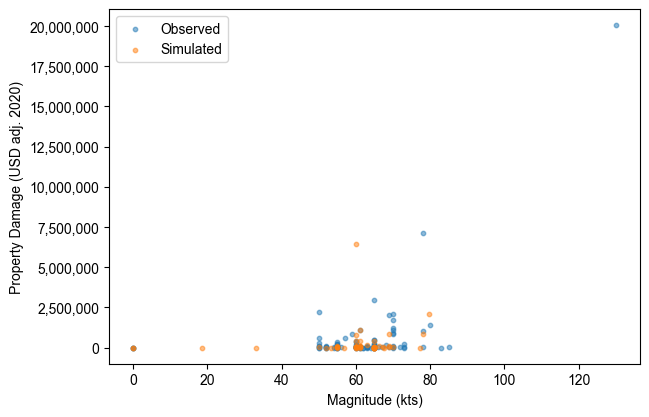

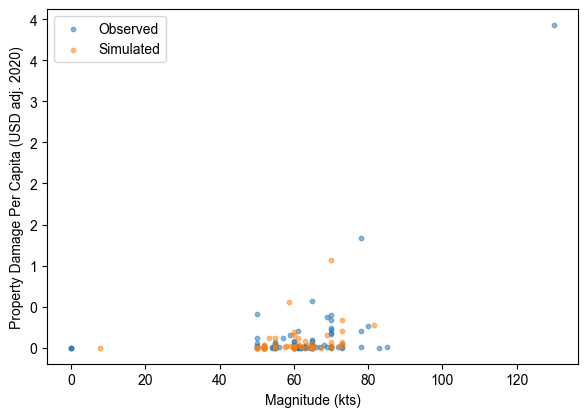

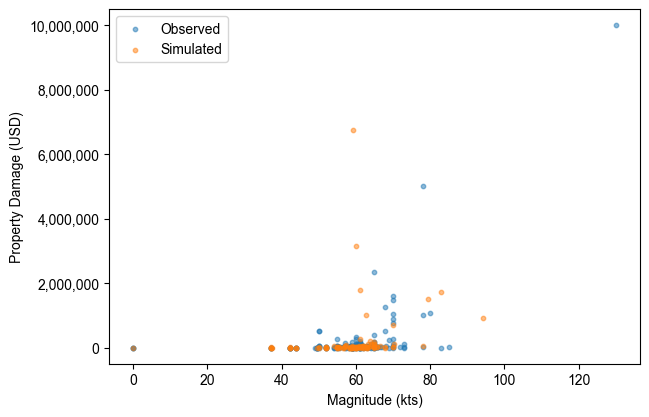

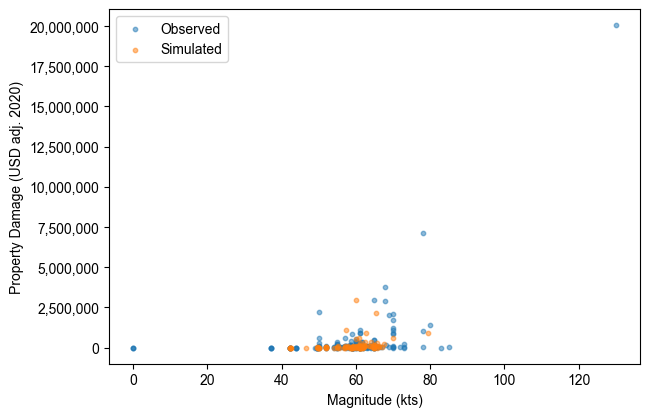

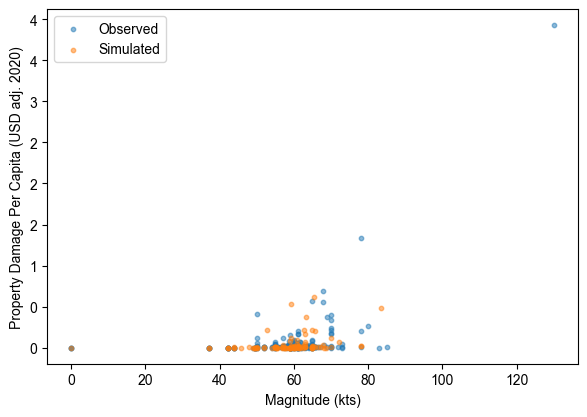

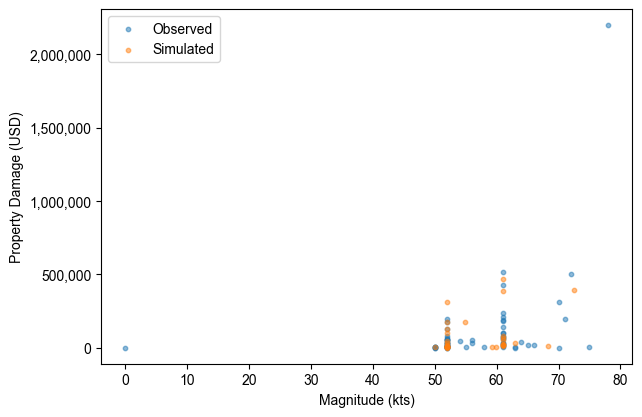

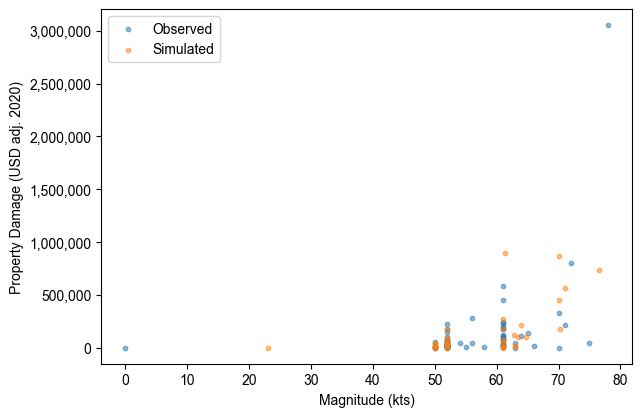

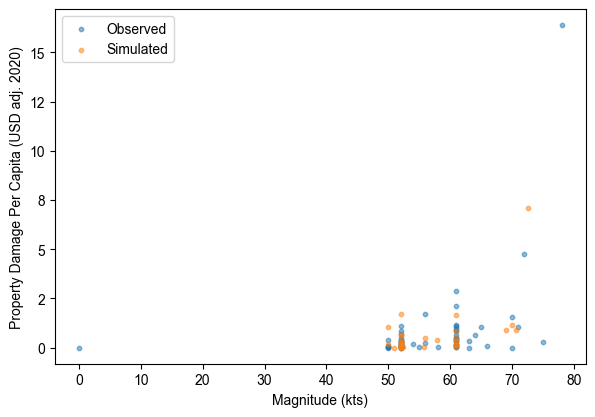

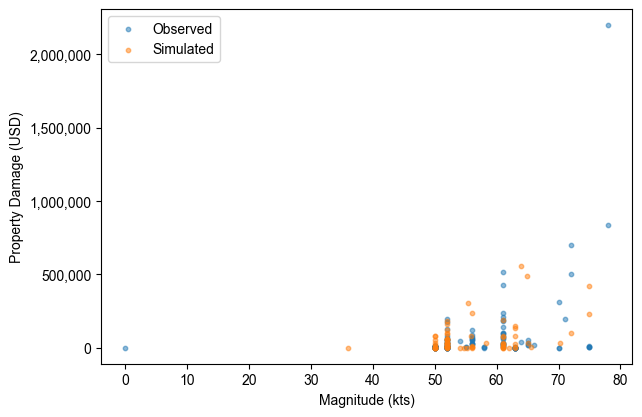

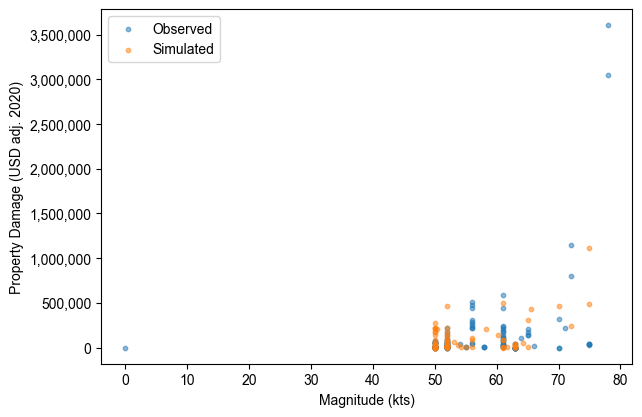

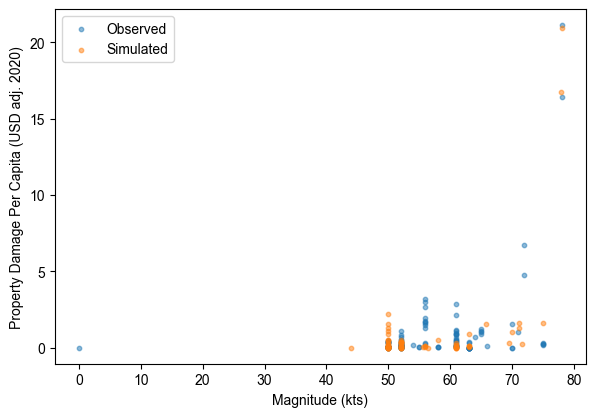

In [ ]:
simRatio = 0.5

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for county in ['Cook IL', 'Champaign IL']:
        for fill in fills:
            for var in dmgs:
                data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
                s = strandMap[(county, fill, var)]
                nSamples = int(len(data) * simRatio)

                sim = pd.DataFrame(s['lineStrand'].sample(nSamples), columns=data.columns)
                simRescaled = rescale(data, sim)

                fig, ax = plt.subplots(figsize=(WIDTH, MAXHEIGHT/2))

                ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
                ax.scatter(data.iloc[:, 0], data.iloc[:, 1], alpha=0.5, s=10, label='Observed')
                ax.scatter(simRescaled.iloc[:, 0], simRescaled.iloc[:, 1], alpha=0.5, s=10, label='Simulated')
                ax.set_xlabel('Magnitude (kts)')
                ax.set_ylabel(var)
                # ax.set_title(f'{county}')
                ax.legend()
                plt.show()

### Image Saving

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


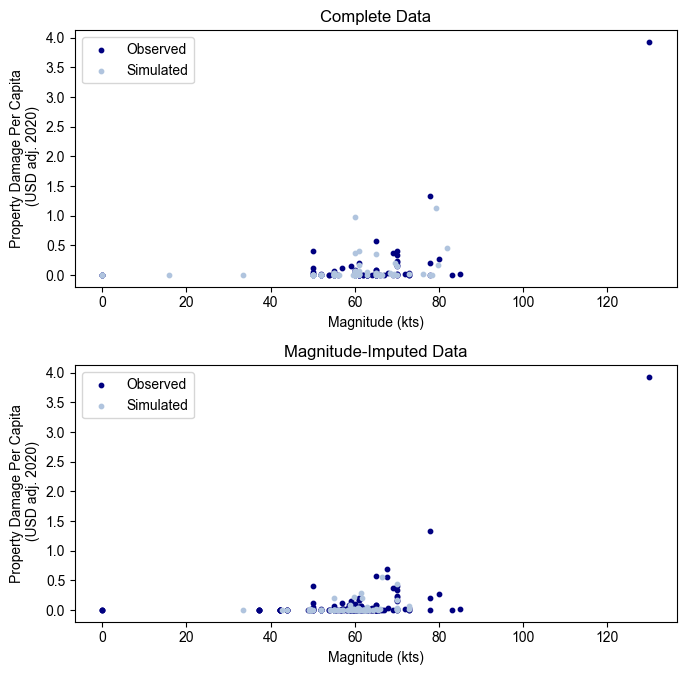

In [343]:
var = 'Property Damage Per Capita (USD adj. 2020)'

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, WIDTH))

    for i, fill in enumerate(fills):
        ax = axes[i]
        data = dataMap[('Cook IL', fill)][['Magnitude', dmgMap['Property Damage Per Capita (USD adj. 2020)']]]
        s = strandMap[('Cook IL', fill, 'Property Damage Per Capita (USD adj. 2020)')]
        nsims = int(len(data) * simRatio)
        
        sim = pd.DataFrame(s['lineStrand'].sample(nSamples), columns=data.columns)
        simRescaled = rescale(data, sim)

        # fig, ax = plt.subplots(figsize=(WIDTH, MAXHEIGHT/2.5))
        ax.scatter(data.iloc[:, 0], data.iloc[:, 1], s=10, label='Observed', color='navy')
        ax.scatter(simRescaled.iloc[:, 0], simRescaled.iloc[:, 1], s=10, label='Simulated', color='lightsteelblue')
        ax.set_xlabel('Magnitude (kts)')
        ax.set_ylabel('Property Damage Per Capita\n (USD adj. 2020)')
        ax.set_title(f'{fill}')
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'Fig23.eps', format='eps', bbox_inches='tight')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


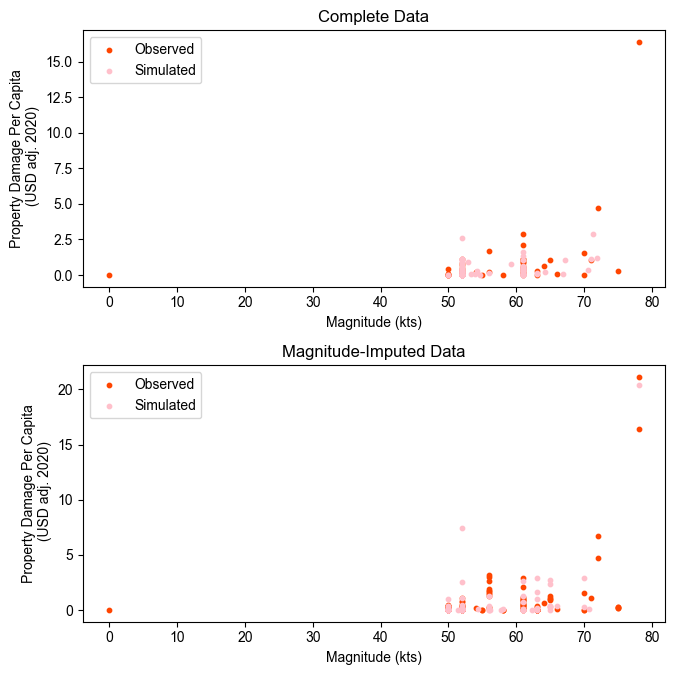

In [344]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, WIDTH))

    for i, fill in enumerate(fills):
        ax = axes[i]
        data = dataMap[('Champaign IL', fill)][['Magnitude', dmgMap['Property Damage Per Capita (USD adj. 2020)']]]
        s = strandMap[('Champaign IL', fill, 'Property Damage Per Capita (USD adj. 2020)')]
        nsims = int(len(data) * simRatio)
        
        sim = pd.DataFrame(s['lineStrand'].sample(nSamples), columns=data.columns)
        simRescaled = rescale(data, sim)

        # fig, ax = plt.subplots(figsize=(WIDTH, MAXHEIGHT/2.5))
        ax.scatter(data.iloc[:, 0], data.iloc[:, 1], s=10, label='Observed', color='orangered')
        ax.scatter(simRescaled.iloc[:, 0], simRescaled.iloc[:, 1], s=10, label='Simulated', color='pink')
        ax.set_xlabel('Magnitude (kts)')
        ax.set_ylabel('Property Damage Per Capita\n (USD adj. 2020)')
        ax.set_title(f'{fill}')
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'Fig25.eps', format='eps', bbox_inches='tight')
    plt.show()

## Goodness-of-Fit Tests

### Kendall Plots

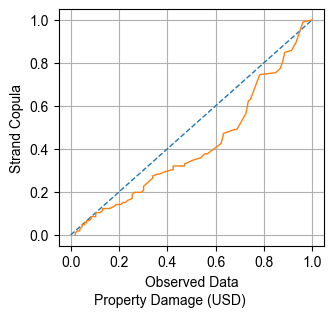

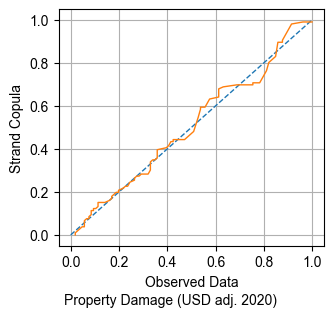

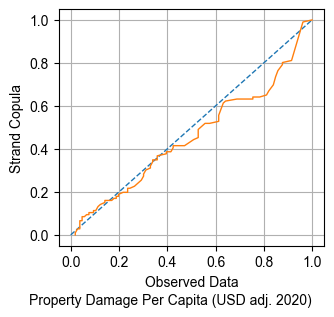

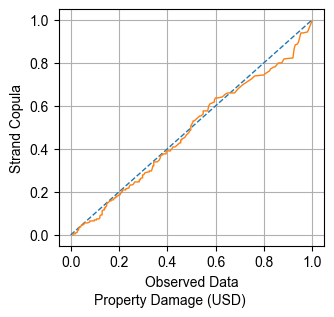

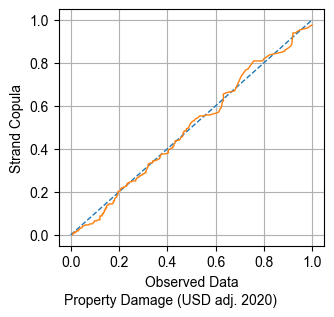

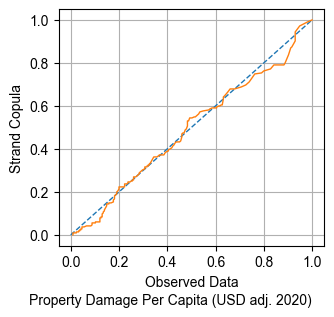

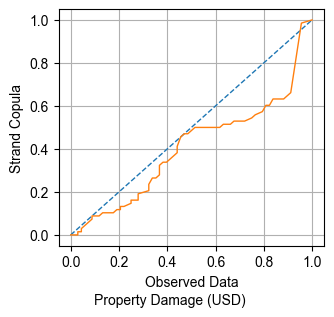

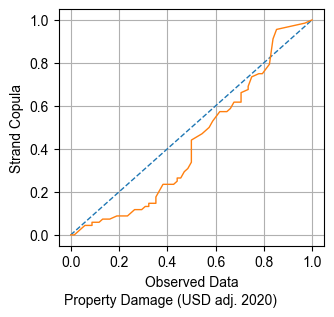

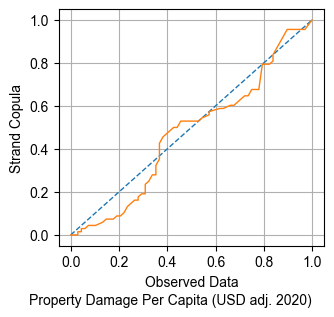

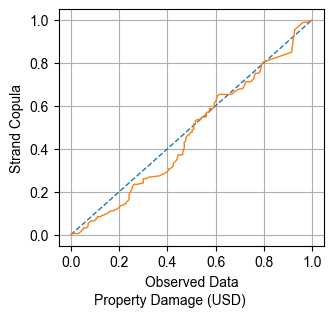

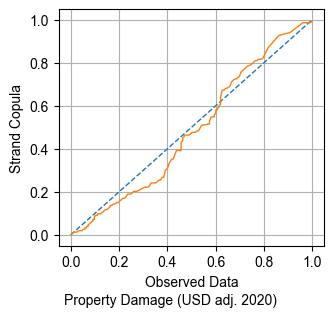

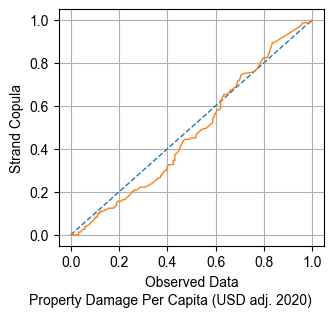

In [214]:
for county in ['Cook IL', 'Champaign IL']:
    for fill in fills:
        for var in dmgs:
            data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
            s = strandMap[(county, fill, var)]

            nSim = int(len(data))
            copSimData = simulate(s['lineStrand'], nSim)

            obsSample = ot.Sample.BuildFromDataFrame(data)
            obsSample.setName('Observed Data')

            simSample = ot.Sample(copSimData)
            simSample.setName('Strand Copula')

            view = viewer.View(
                ot.VisualTest.DrawKendallPlot(obsSample, simSample),
                figure_kw={'figsize': (WIDTH/2, MAXHEIGHT/3)}
            )
            fig = plt.gcf()
            for text in fig.texts:
                text.set_visible(False)
            fig.axes[0].set_title('')
            fig.text(0.45, -0.08, f'{var}', ha='center', fontsize=10)
            plt.show()

### Image Saving

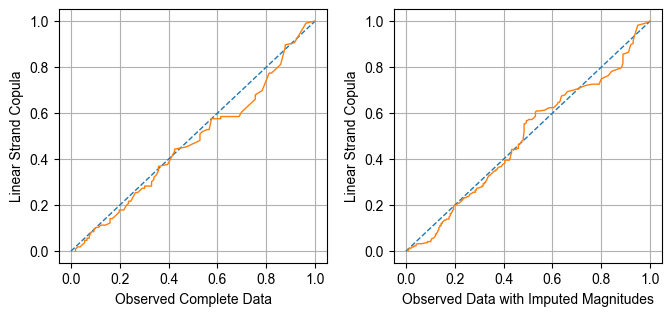

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(WIDTH, WIDTH/2))
var = 'Property Damage Per Capita (USD adj. 2020)'
county = 'Cook IL'

for fill, ax in zip(fills, axes):
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
    s = strandMap[(county, fill, var)]
    nSim = int(len(data))

    copSimData = simulate(s['lineStrand'], nSim)

    obsSample = ot.Sample.BuildFromDataFrame(data)
    if fill == 'Complete Data':
        obsSample.setName('Observed Complete Data')
    else:
        obsSample.setName('Observed Data with Imputed Magnitudes')

    simSample = ot.Sample(copSimData)
    simSample.setName('Piecewise Linear Strand Copula')

    view = viewer.View(
        ot.VisualTest.DrawKendallPlot(obsSample, simSample),
        axes=[ax]
    )

    for text in fig.texts:
        text.set_visible(False)
    ax.set_title('')

plt.tight_layout()
plt.savefig(f'Fig24.eps', format='eps', bbox_inches='tight')
plt.show()

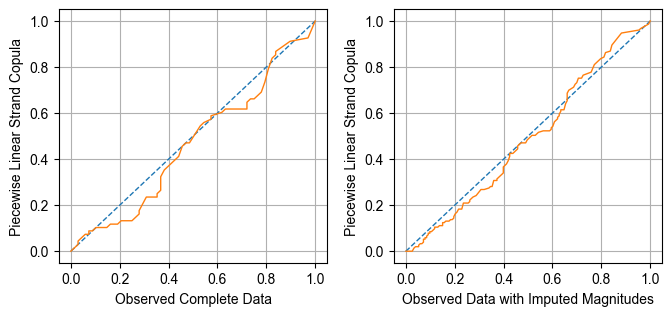

In [365]:
fig, axes = plt.subplots(1, 2, figsize=(WIDTH, WIDTH/2))
county = 'Champaign IL'
var = 'Property Damage Per Capita (USD adj. 2020)'

for fill, ax in zip(fills, axes):
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
    s = strandMap[(county, fill, var)]
    nSim = int(len(data))

    copSimData = simulate(s['lineStrand'], nSim)

    obsSample = ot.Sample.BuildFromDataFrame(data)
    if fill == 'Complete Data':
        obsSample.setName('Observed Complete Data')
    else:
        obsSample.setName('Observed Data with Imputed Magnitudes')
    simSample = ot.Sample(copSimData)
    simSample.setName('Piecewise Linear Strand Copula')

    view = viewer.View(
        ot.VisualTest.DrawKendallPlot(obsSample, simSample),
        axes=[ax]
    )

    for text in fig.texts:
        text.set_visible(False)
    ax.set_title('')

plt.tight_layout()
plt.savefig(f'Fig26.eps', format='eps', bbox_inches='tight')
plt.show()

### 2-Dimensional Kolmogorov-Smirnov Tests

In [289]:
np.random.seed(42)

results = {}

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for county in ['Cook IL', 'Champaign IL']:
        county_results = {}
        for fill in fills:
            for var in dmgs:
                obs = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
                s = strandMap[(county, fill, var)]

                sim = pd.DataFrame(simulate(s['lineStrand'], len(data)), columns=obs.columns)
                simRescaled = rescale(obs, sim)

                gabinou, li = ksTests(obs, sim, simRescaled)

                county_results[(fill, var)] = pd.concat(
                    [gabinou, li],
                    keys=['Gabinou (2018)', 'Zhaozhou Li (2019)'],
                    axis=1
                )
        results[county] = county_results

# Display combined tables per fill × damage type
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for fill in fills:
        for var in dmgs:
            print(f'\n--- {fill} | {var} ---')
            combined = pd.concat(
                [results['Cook IL'][(fill, var)], results['Champaign IL'][(fill, var)]],
                keys=['Cook IL', 'Champaign IL'],
                axis=1
            )
            display(combined)


--- Complete data only | Property Damage (USD) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation             0.08745  0.858394           0.079470  0.923567   
Rescaled Simulation        0.05386  0.998991           0.060293  0.994667   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.202522  0.091649           0.209721  0.073328  
Rescaled Simulation       0.078110  0.975841           0.083145  0.957316


--- Complete data only | Property Damage (USD adj. 2020) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.093913  0.793401           0.096037  0.770363   
Rescaled Simulation       0.067241  0.980501           0.070488  0.969171   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.195511  0.116211           0.195464  0.116370  
Rescaled Simulation       0.078346  0.975741           0.086957  0.939896


--- Complete data only | Property Damage Per Capita (USD adj. 2020) ---


...

Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.084265  0.729913           0.078704  0.802358   
Rescaled Simulation       0.057359  0.980406           0.059644  0.971279   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.152597  0.135485           0.159091  0.107239  
Rescaled Simulation       0.074675  0.903685           0.071429  0.929440


--- Magnitude only imputed | Property Damage (USD adj. 2020) ---


Cook IL                                        \
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic  p-Value   
Raw Simulation            0.073984  0.853073           0.070346  0.89151   
Rescaled Simulation       0.061027  0.963395           0.056608  0.98223   

                      Champaign IL                                        
                    Gabinou (2018)           Zhaozhou Li (2019)           
                         Statistic   p-Value          Statistic  p-Value  
Raw Simulation            0.165584  0.085160           0.165584  0.08516  
Rescaled Simulation       0.077922  0.870825           0.084416  0.80034


--- Magnitude only imputed | Property Damage Per Capita (USD adj. 2020) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.061809  0.959097           0.063763  0.947046   
Rescaled Simulation       0.051587  0.993953           0.054533  0.988200   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.159091  0.108080           0.162338  0.095833  
Rescaled Simulation       0.064935  0.966391           0.068182  0.948989

In [290]:
np.random.seed(42)

def strandSim(data, county, fill, var):
    s = strandMap[(county, fill, var)]
    sim = pd.DataFrame(simulate(s['lineStrand'], len(data)), columns=data.columns)
    simRescaled = rescale(data, sim)
    return sim, simRescaled

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for fill in fills:
        for var in dmgs:
            print(f'\n--- {fill} | {var} ---')
            ckData = dataMap[('Cook IL', fill)][['Magnitude', dmgMap[var]]]
            chData = dataMap[('Champaign IL', fill)][['Magnitude', dmgMap[var]]]

            combined = pd.concat(
                [ksRejectionRate(ckData, lambda data: strandSim(data, 'Cook IL', fill, var)),
                 ksRejectionRate(chData, lambda data: strandSim(data, 'Champaign IL', fill, var))],
                keys=['Cook IL', 'Champaign IL'],
                axis=1
            )
            display(combined.style.format("{:.2%}"))


--- Complete data only | Property Damage (USD) ---



--- Complete data only | Property Damage (USD adj. 2020) ---



--- Complete data only | Property Damage Per Capita (USD adj. 2020) ---



--- Magnitude only imputed | Property Damage (USD) ---



--- Magnitude only imputed | Property Damage (USD adj. 2020) ---



--- Magnitude only imputed | Property Damage Per Capita (USD adj. 2020) ---


# Polynomial c3

Polynomial strands fit indicator correlations as functions of the parameter threshold. Indicator correlations can be polynomially evaluated using their given normal threshold quantile.

## Fitting

In [ ]:
# Cook IL — Complete data only
county, fill = 'Cook IL', 'Complete Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    polynomialStrand, polyLow, polyUp = fitData(data, form='poly', max=3, nThresh=30)
    
    strandMap[(county, fill, var)]['polynomialStrand'] = polynomialStrand
    strandMap[(county, fill, var)]['polyLow'] = polyLow
    strandMap[(county, fill, var)]['polyUp'] = polyUp

Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge


In [ ]:
# Cook IL — Magnitude only imputed
county, fill = 'Cook IL', 'Magnitude-Imputed Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    polynomialStrand, polyLow, polyUp = fitData(data, form='poly', max=4, nThresh=30)
    
    strandMap[(county, fill, var)]['polynomialStrand'] = polynomialStrand
    strandMap[(county, fill, var)]['polyLow'] = polyLow
    strandMap[(county, fill, var)]['polyUp'] = polyUp

Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge


In [ ]:
# Champaign IL — Complete data only
county, fill = 'Champaign IL', 'Complete Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    polynomialStrand, polyLow, polyUp = fitData(data, form='poly', max=4, nThresh=30)
    
    strandMap[(county, fill, var)]['polynomialStrand'] = polynomialStrand
    strandMap[(county, fill, var)]['polyLow'] = polyLow
    strandMap[(county, fill, var)]['polyUp'] = polyUp

Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge


In [ ]:
# Champaign IL — Magnitude only imputed
county, fill = 'Champaign IL', 'Magnitude-Imputed Data'
for var in dmgs:
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]].astype(float)
    polynomialStrand, polyLow, polyUp = fitData(data, form='poly', max=4, nThresh=30)
    
    strandMap[(county, fill, var)]['polynomialStrand'] = polynomialStrand
    strandMap[(county, fill, var)]['polyLow'] = polyLow
    strandMap[(county, fill, var)]['polyUp'] = polyUp

Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge
Polynomial fitting did not perfectly converge


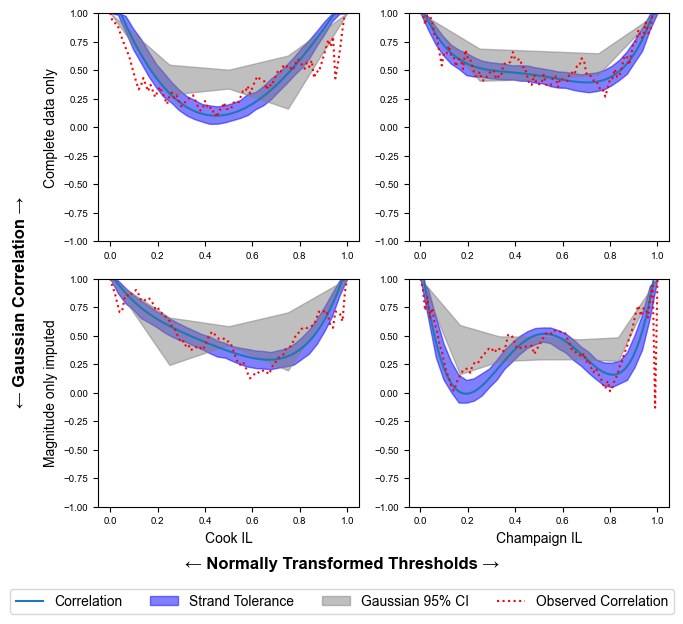

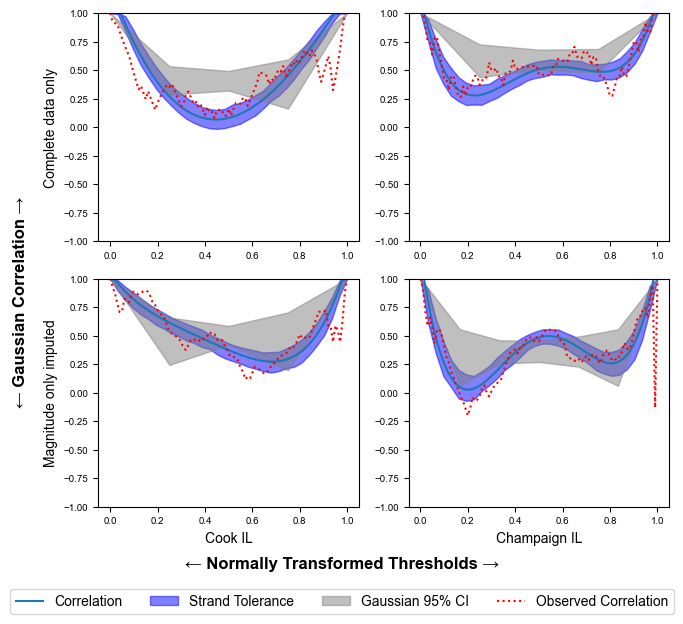

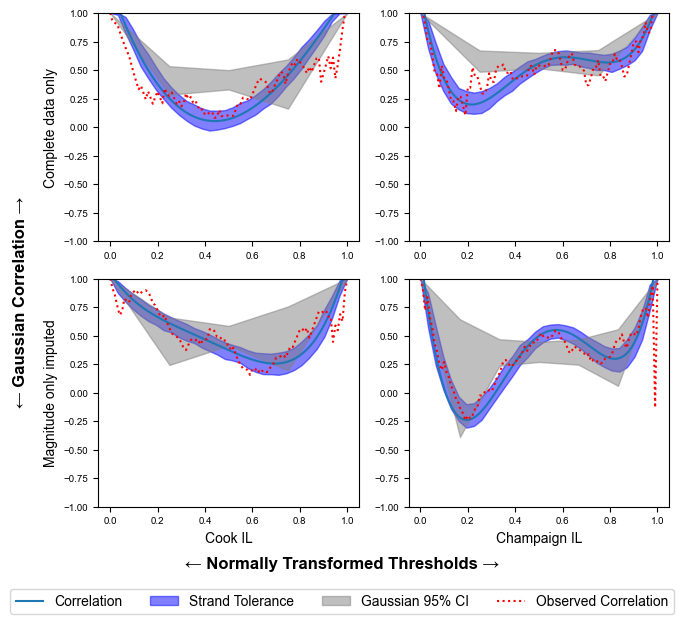

In [221]:
for var in dmgs:
    fig, axes = plt.subplots(len(fills), 2, figsize=(WIDTH, MAXHEIGHT*2/3))

    for i, fill in enumerate(fills):
        axes[i, 0].set_ylabel(fill, fontsize=10)
        for k, county in enumerate(['Cook IL', 'Champaign IL']):
            ax = axes[i, k]
            s = strandMap[(county, fill, var)]

            ax = plotStrand(s['polynomialStrand'], ax, label='Correlation')
            ax = plotInterval(np.linspace(0., 1., len(s['polyLow'])), s['polyLow'], s['polyUp'], ax=ax, color='blue', alpha=0.5, label='Strand Tolerance')
            ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gray', alpha=0.5, label='Gaussian 95% CI')
            ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')
            
            ax.set_ylim(-1, 1)
            ax.tick_params(labelsize=7)

    for k, county in enumerate(['Cook IL', 'Champaign IL']):
        axes[-1, k].set_xlabel(county, fontsize=10)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
    fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
    fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.show()

### Image Saving

#### Main

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


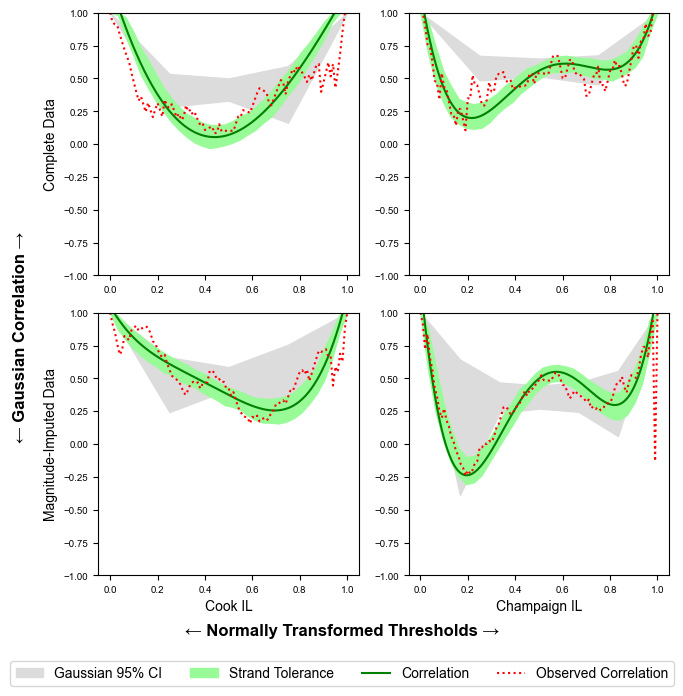

In [345]:
var = 'Property Damage Per Capita (USD adj. 2020)'

fig, axes = plt.subplots(len(fills), 2, figsize=(WIDTH, len(fills)*WIDTH/2))

for i, fill in enumerate(fills):
    axes[i, 0].set_ylabel(fill, fontsize=10)
    for k, county in enumerate(['Cook IL', 'Champaign IL']):
        ax = axes[i, k]
        s = strandMap[(county, fill, var)]

        ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gainsboro', label='Gaussian 95% CI')

        ax = plotInterval(np.linspace(0., 1., len(s['polyLow'])), s['polyLow'], s['polyUp'], ax=ax, color='palegreen', label='Strand Tolerance')
        ax = plotStrand(s['polynomialStrand'], ax, label='Correlation', color='green')
        ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

        ax.set_ylim(-1, 1)
        ax.tick_params(labelsize=7)

for k, county in enumerate(['Cook IL', 'Champaign IL']):
    axes[-1, k].set_xlabel(county, fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'Fig10.eps', format='eps', bbox_inches='tight')
plt.show()

#### Appendix

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


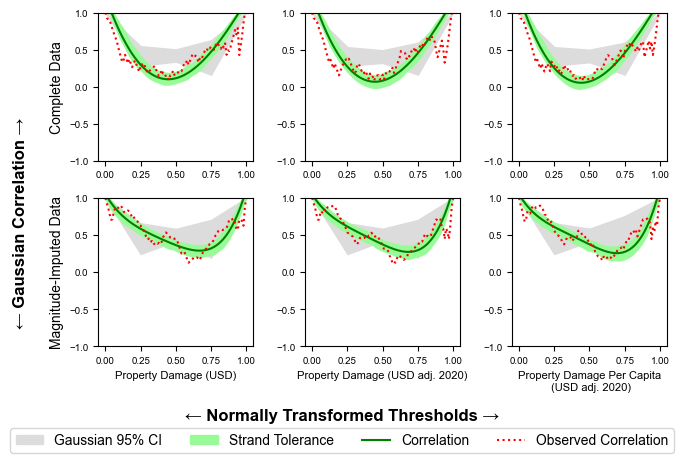

In [346]:
county = 'Cook IL'
fig, axes = plt.subplots(len(fills), len(dmgs), figsize=(WIDTH, len(fills)*WIDTH/len(dmgs)))

for i, fill in enumerate(fills):
    axes[i, 0].set_ylabel(fill, fontsize=10)
    for k, var in enumerate(dmgs):
        ax = axes[i, k]
        s = strandMap[(county, fill, var)]

        ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gainsboro', label='Gaussian 95% CI')

        ax = plotInterval(np.linspace(0., 1., len(s['polyLow'])), s['polyLow'], s['polyUp'], ax=ax, color='palegreen', label='Strand Tolerance')
        ax = plotStrand(s['polynomialStrand'], ax, label='Correlation', color='green')
        ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

        ax.set_ylim(-1, 1)
        ax.tick_params(labelsize=7)

# Set column x-labels once, outside the fill loop, on the bottom row only
for k, var in enumerate(dmgs):
    if 'Per Capita' in var:
        label = var.replace('Per Capita', 'Per Capita\n')
    else:
        label = var
    axes[-1, k].set_xlabel(label, fontsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'Fig17.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


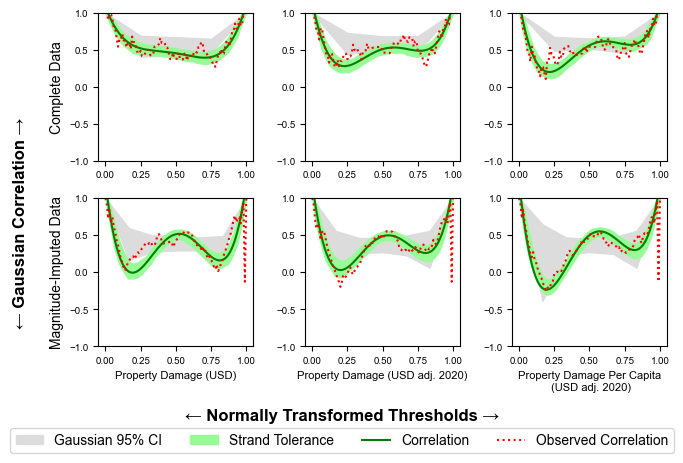

In [347]:
county = 'Champaign IL'
fig, axes = plt.subplots(len(fills), len(dmgs), figsize=(WIDTH, len(fills)*WIDTH/len(dmgs)))

for i, fill in enumerate(fills):
    axes[i, 0].set_ylabel(fill, fontsize=10)
    for k, var in enumerate(dmgs):
        ax = axes[i, k]
        s = strandMap[(county, fill, var)]

        ax = plotInterval(np.linspace(0., 1., len(s['gaussLow'])), s['gaussLow'], s['gaussUp'], ax=ax, color='gainsboro', label='Gaussian 95% CI')

        ax = plotInterval(np.linspace(0., 1., len(s['polyLow'])), s['polyLow'], s['polyUp'], ax=ax, color='palegreen', label='Strand Tolerance')
        ax = plotStrand(s['polynomialStrand'], ax, label='Correlation', color='green')
        ax.plot(np.linspace(0., 1., 101), s['obsCorrs'], label='Observed Correlation', color='red', ls=':')

        ax.set_ylim(-1, 1)
        ax.tick_params(labelsize=7)

# Set column x-labels once, outside the fill loop, on the bottom row only
for k, var in enumerate(dmgs):
    if 'Per Capita' in var:
        label = var.replace('Per Capita', 'Per Capita\n')
    else:
        label = var
    axes[-1, k].set_xlabel(label, fontsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(labels), fontsize=10, bbox_to_anchor=(0.5, -0.02))
fig.supxlabel('← Normally Transformed Thresholds →', fontsize=12, fontweight='bold', y=0.06)
fig.supylabel('← Gaussian Correlation →', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig(f'Fig18.eps', format='eps', bbox_inches='tight')
plt.show()

## Simulation

### All Simulations

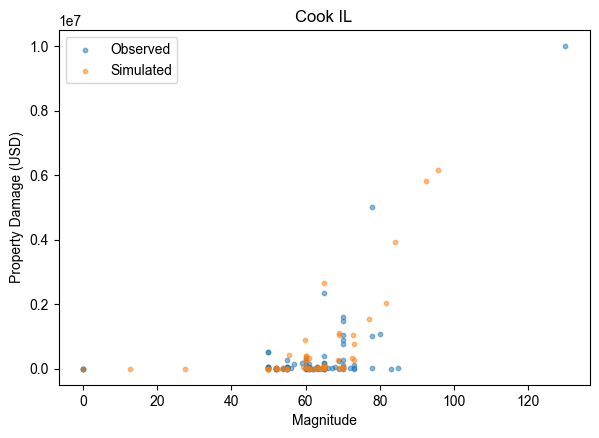

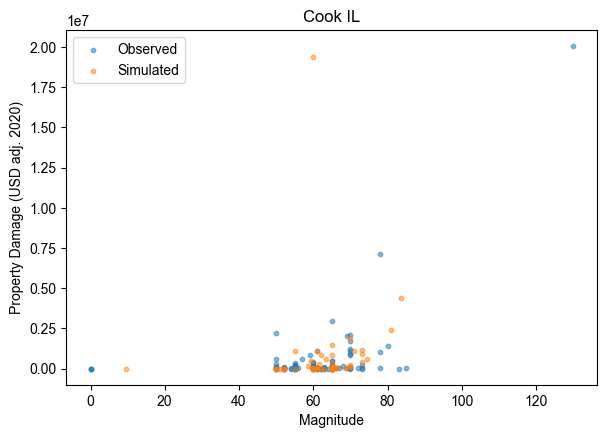

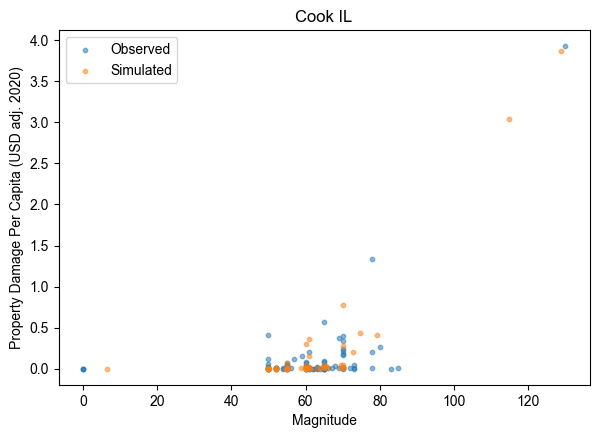

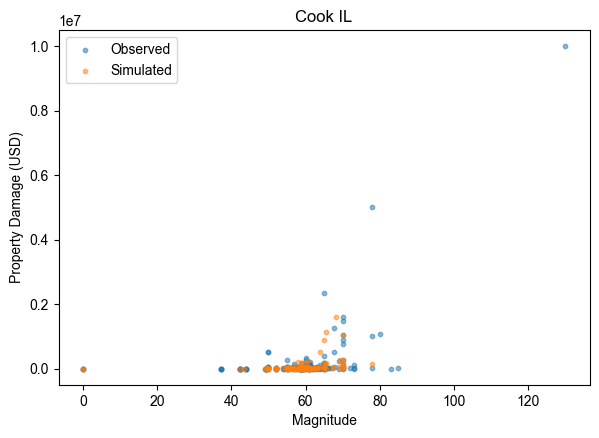

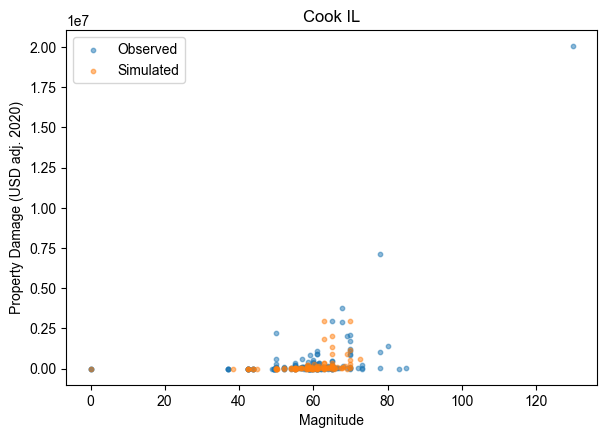

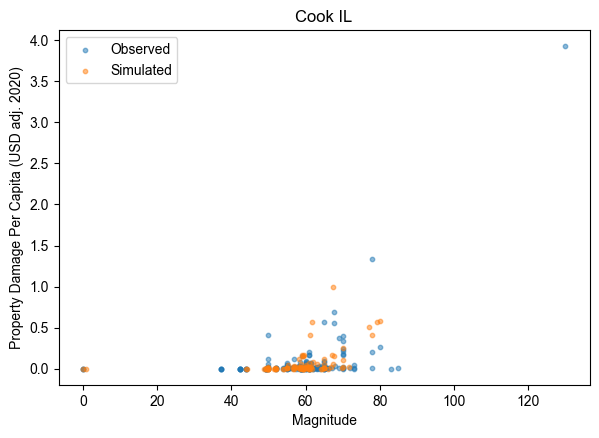

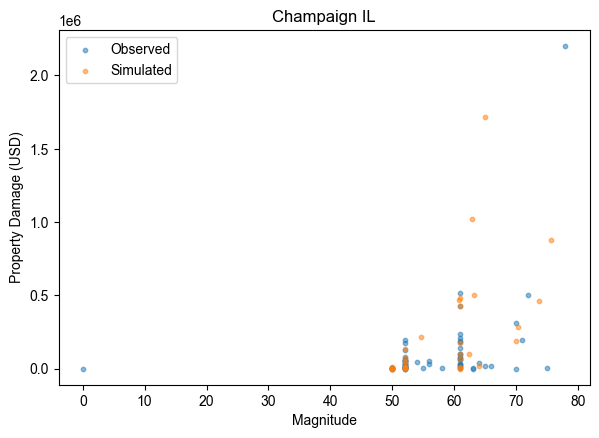

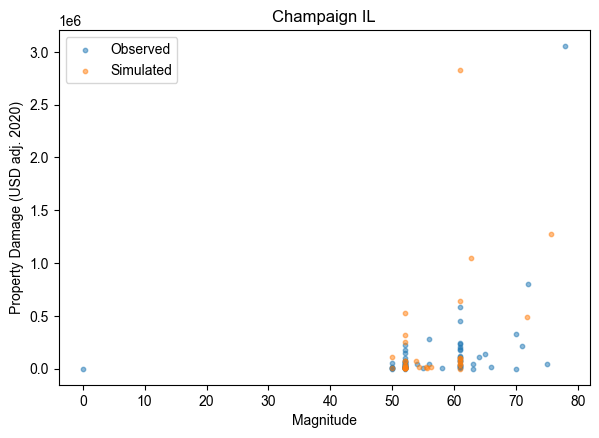

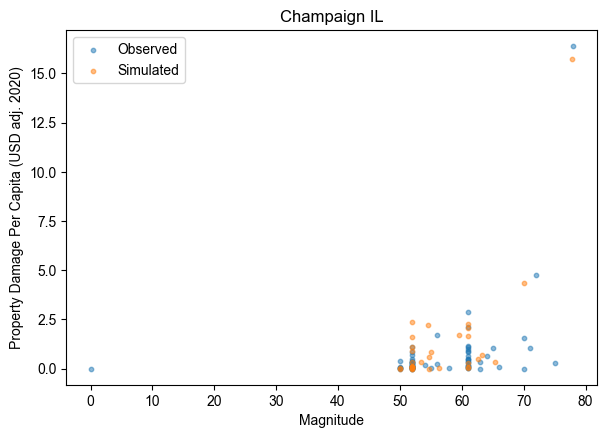

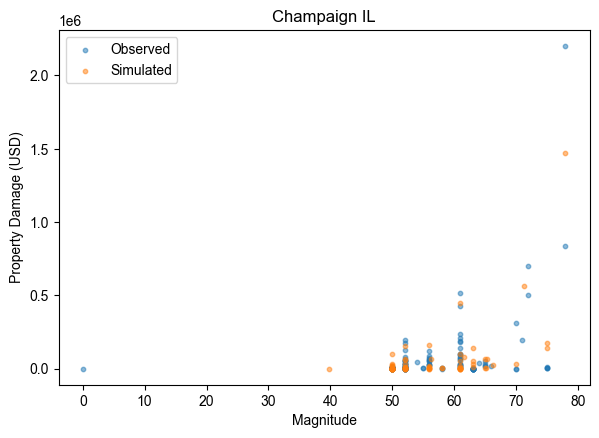

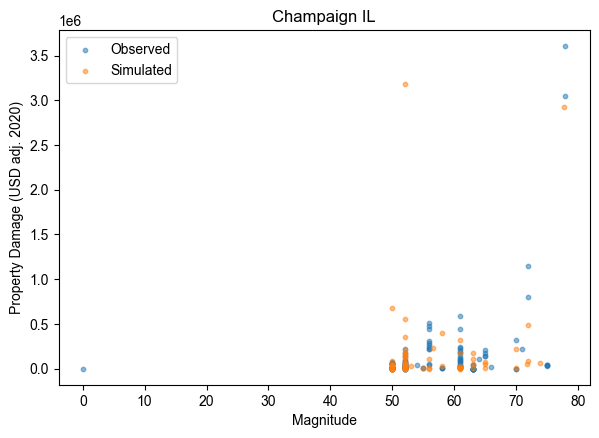

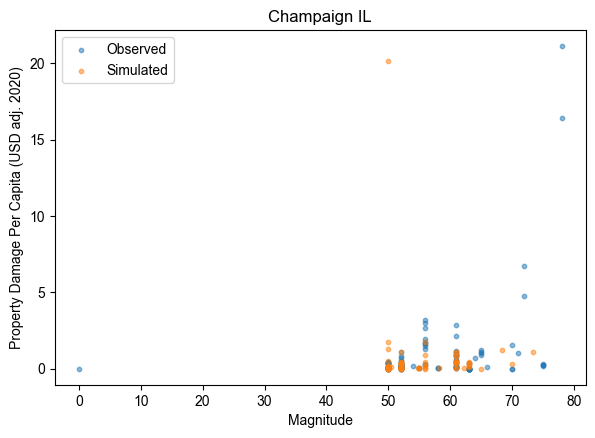

In [223]:
simRatio = 0.5

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for county in ['Cook IL', 'Champaign IL']:
        for fill in fills:
            for var in dmgs:
                data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
                s = strandMap[(county, fill, var)]
                nSamples = int(len(data) * simRatio)

                sim = pd.DataFrame(s['polynomialStrand'].sample(nSamples), columns=data.columns)
                simRescaled = rescale(data, sim)

                fig, ax = plt.subplots(figsize=(WIDTH, MAXHEIGHT/2))

                ax.scatter(data.iloc[:, 0], data.iloc[:, 1], alpha=0.5, s=10, label='Observed')
                ax.scatter(simRescaled.iloc[:, 0], simRescaled.iloc[:, 1], alpha=0.5, s=10, label='Simulated')
                ax.set_xlabel('Magnitude')
                ax.set_ylabel(var)
                ax.set_title(f'{county}')
                ax.legend()
                plt.show()

### Image Saving

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


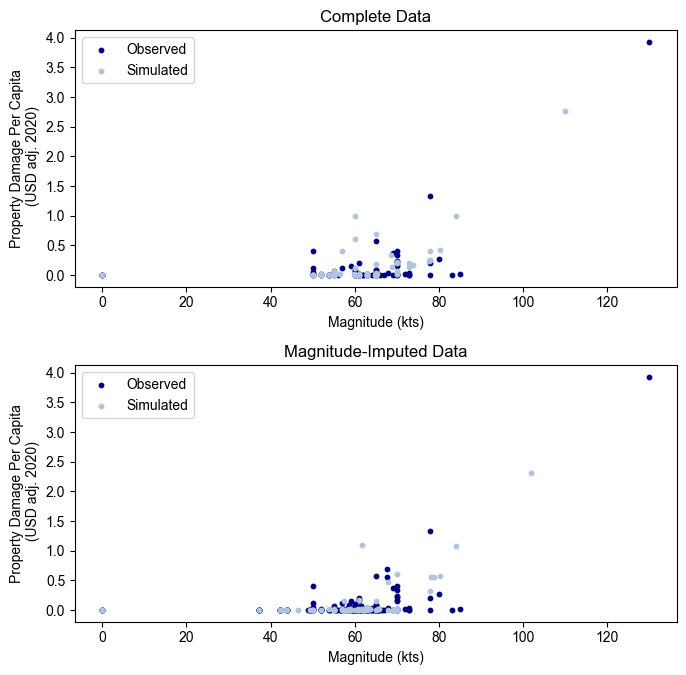

In [337]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, WIDTH))

    for i, fill in enumerate(fills):
        ax = axes[i]
        data = dataMap[('Cook IL', fill)][['Magnitude', dmgMap['Property Damage Per Capita (USD adj. 2020)']]]
        s = strandMap[('Cook IL', fill, 'Property Damage Per Capita (USD adj. 2020)')]
        nsims = int(len(data) * simRatio)
        
        sim = pd.DataFrame(s['polynomialStrand'].sample(nSamples), columns=data.columns)
        simRescaled = rescale(data, sim)

        ax.scatter(data.iloc[:, 0], data.iloc[:, 1], s=10, label='Observed', color='navy')
        ax.scatter(simRescaled.iloc[:, 0], simRescaled.iloc[:, 1], s=10, label='Simulated', color='lightsteelblue')
        ax.set_xlabel('Magnitude (kts)')
        ax.set_ylabel('Property Damage Per Capita\n (USD adj. 2020)')
        ax.set_title(f'{fill}')
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'Fig27.eps', format='eps', bbox_inches='tight')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


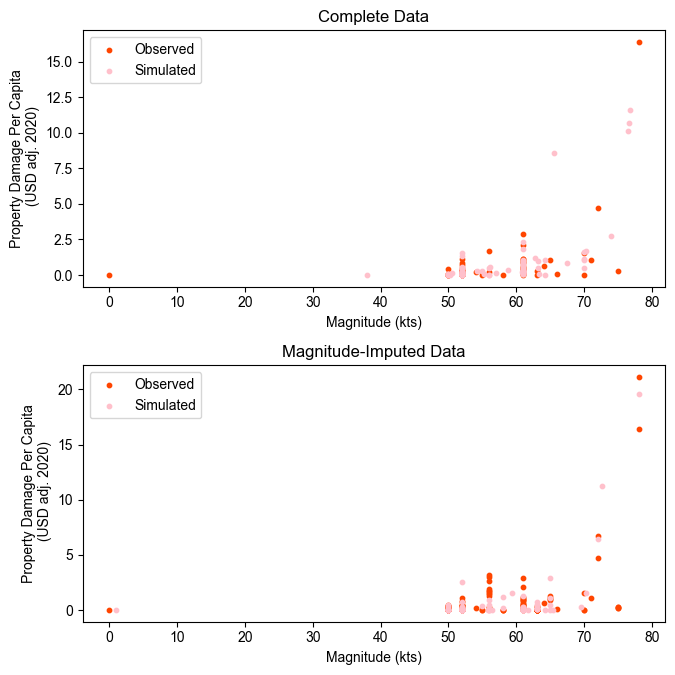

In [368]:
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    fig, axes = plt.subplots(2, 1, figsize=(WIDTH, WIDTH))

    for i, fill in enumerate(fills):
        ax = axes[i]
        data = dataMap[('Champaign IL', fill)][['Magnitude', dmgMap['Property Damage Per Capita (USD adj. 2020)']]]
        s = strandMap[('Champaign IL', fill, 'Property Damage Per Capita (USD adj. 2020)')]
        nsims = int(len(data) * simRatio)
        
        sim = pd.DataFrame(s['polynomialStrand'].sample(nSamples), columns=data.columns)
        simRescaled = rescale(data, sim)

        ax.scatter(data.iloc[:, 0], data.iloc[:, 1], s=10, label='Observed', color='orangered')
        ax.scatter(simRescaled.iloc[:, 0], simRescaled.iloc[:, 1], s=10, label='Simulated', color='pink')
        ax.set_xlabel('Magnitude (kts)')
        ax.set_ylabel('Property Damage Per Capita\n (USD adj. 2020)')
        ax.set_title(f'{fill}')
        ax.legend()

    plt.tight_layout()
    plt.savefig(f'Fig29.eps', format='eps', bbox_inches='tight')
    plt.show()

## Goodness-of-Fit Tests

### Kendall Plots

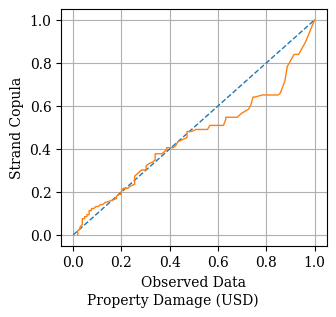

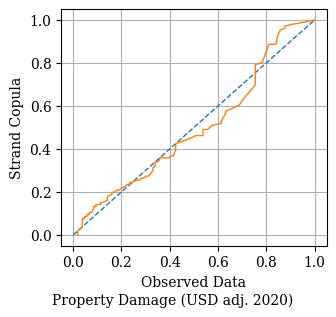

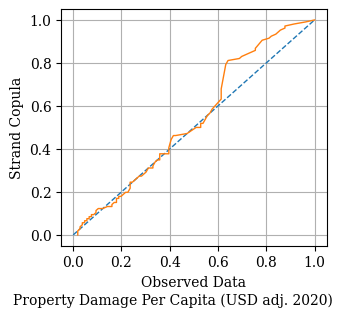

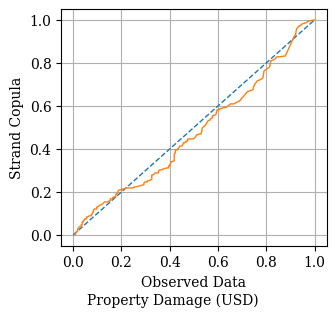

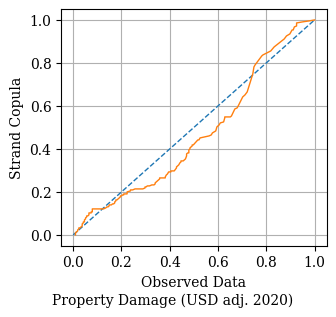

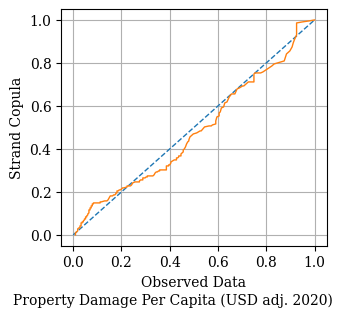

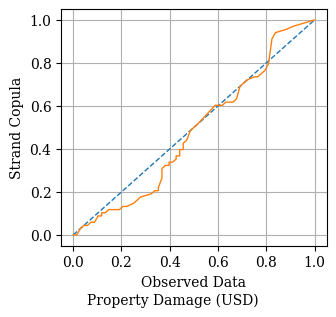

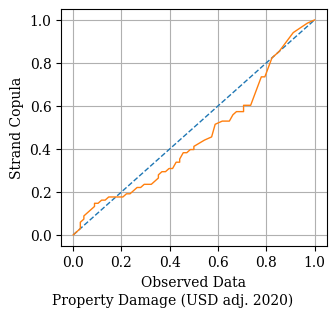

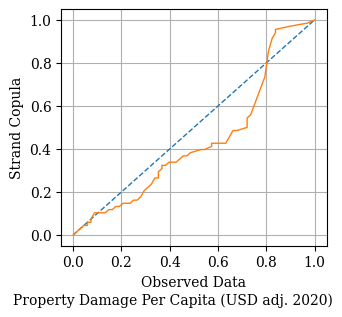

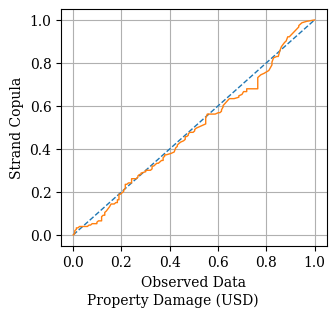

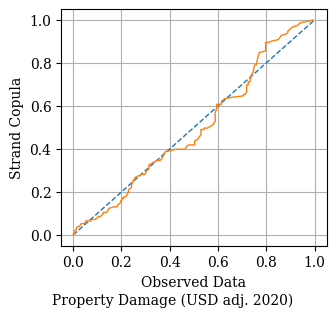

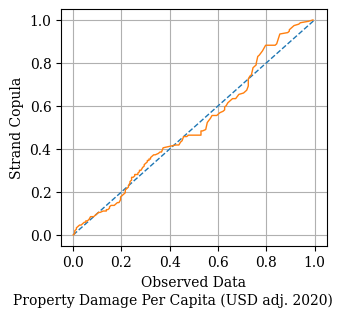

In [36]:
for county in ['Cook IL', 'Champaign IL']:
    for fill in fills:
        for var in dmgs:
            data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
            s = strandMap[(county, fill, var)]

            nSim = int(len(data))
            copSimData = simulate(s['polynomialStrand'], nSim)

            obsSample = ot.Sample.BuildFromDataFrame(data)
            obsSample.setName('Observed Data')

            simSample = ot.Sample(copSimData)
            simSample.setName('Strand Copula')

            view = viewer.View(
                ot.VisualTest.DrawKendallPlot(obsSample, simSample),
                figure_kw={'figsize': (WIDTH/2, MAXHEIGHT/3)}
            )
            fig = plt.gcf()
            for text in fig.texts:
                text.set_visible(False)
            fig.axes[0].set_title('')
            fig.text(0.45, -0.08, f'{var}', ha='center', fontsize=10)
            plt.show()

### Image Saving

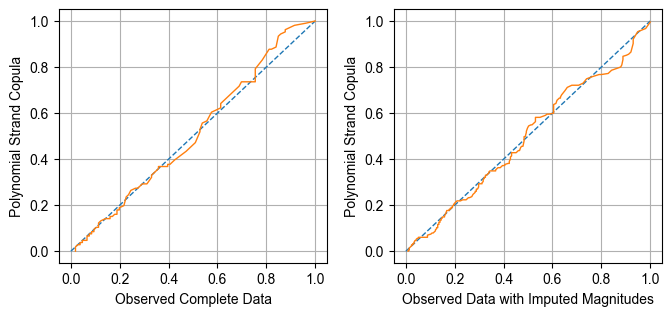

In [372]:
fig, axes = plt.subplots(1, 2, figsize=(WIDTH, WIDTH/2))
var = 'Property Damage Per Capita (USD adj. 2020)'
county = 'Cook IL'

for fill, ax in zip(fills, axes):
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
    s = strandMap[(county, fill, var)]
    nSim = int(len(data))

    copSimData = simulate(s['polynomialStrand'], nSim)

    obsSample = ot.Sample.BuildFromDataFrame(data)
    if fill == 'Complete Data':
        obsSample.setName('Observed Complete Data')
    else:
        obsSample.setName('Observed Data with Imputed Magnitudes')

    simSample = ot.Sample(copSimData)
    simSample.setName('Polynomial Strand Copula')

    view = viewer.View(
        ot.VisualTest.DrawKendallPlot(obsSample, simSample),
        axes=[ax]
    )

    for text in fig.texts:
        text.set_visible(False)
    ax.set_title('')

plt.tight_layout()
plt.savefig(f'Fig28.eps', format='eps', bbox_inches='tight')
plt.show()

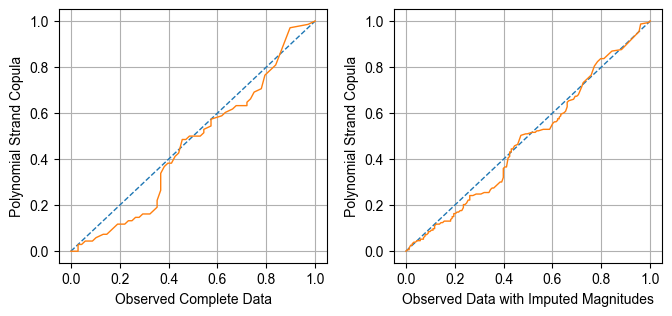

In [371]:
fig, axes = plt.subplots(1, 2, figsize=(WIDTH, WIDTH/2))
county = 'Champaign IL'
var = 'Property Damage Per Capita (USD adj. 2020)'

for fill, ax in zip(fills, axes):
    data = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
    s = strandMap[(county, fill, var)]
    nSim = int(len(data))

    copSimData = simulate(s['polynomialStrand'], nSim)

    obsSample = ot.Sample.BuildFromDataFrame(data)
    if fill == 'Complete Data':
        obsSample.setName('Observed Complete Data')
    else:
        obsSample.setName('Observed Data with Imputed Magnitudes')

    simSample = ot.Sample(copSimData)
    simSample.setName('Polynomial Strand Copula')

    view = viewer.View(
        ot.VisualTest.DrawKendallPlot(obsSample, simSample),
        axes=[ax]
    )

    for text in fig.texts:
        text.set_visible(False)
    ax.set_title('')

plt.tight_layout()
plt.savefig(f'Fig30.eps', format='eps', bbox_inches='tight')
plt.show()

### 2-Dimensional Kolmogorov-Smirnov Tests

In [291]:
np.random.seed(42)

results = {}

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for county in ['Cook IL', 'Champaign IL']:
        county_results = {}
        for fill in fills:
            for var in dmgs:
                obs = dataMap[(county, fill)][['Magnitude', dmgMap[var]]]
                s = strandMap[(county, fill, var)]

                sim = pd.DataFrame(simulate(s['polynomialStrand'], len(data)), columns=obs.columns)
                simRescaled = rescale(obs, sim)

                gabinou, li = ksTests(obs, sim, simRescaled)

                county_results[(fill, var)] = pd.concat(
                    [gabinou, li],
                    keys=['Gabinou (2018)', 'Zhaozhou Li (2019)'],
                    axis=1
                )
        results[county] = county_results

# Display combined tables per fill × damage type
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for fill in fills:
        for var in dmgs:
            print(f'\n--- {fill} | {var} ---')
            combined = pd.concat(
                [results['Cook IL'][(fill, var)], results['Champaign IL'][(fill, var)]],
                keys=['Cook IL', 'Champaign IL'],
                axis=1
            )
            display(combined)


--- Complete data only | Property Damage (USD) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.092153  0.810283           0.088178  0.850059   
Rescaled Simulation       0.053860  0.998890           0.063752  0.988688   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.200922  0.095896           0.201628  0.093869  
Rescaled Simulation       0.067053  0.995881           0.081310  0.964890


--- Complete data only | Property Damage (USD adj. 2020) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.100710  0.715688           0.105231  0.663201   
Rescaled Simulation       0.080228  0.911458           0.083475  0.885231   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.192923  0.122897           0.196311  0.111339  
Rescaled Simulation       0.060982  0.999034           0.060982  0.999034


--- Complete data only | Property Damage Per Capita (USD adj. 2020) ---


...

Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.072240  0.874991           0.066679  0.926572   
Rescaled Simulation       0.050084  0.995867           0.054383  0.988475   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.162338  0.096122           0.162338  0.096122  
Rescaled Simulation       0.084416  0.805591           0.087662  0.767144


--- Magnitude only imputed | Property Damage (USD adj. 2020) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.078163  0.801643            0.07200  0.873438   
Rescaled Simulation       0.063282  0.949533            0.06743  0.918425   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.172078  0.066470           0.172078  0.066470  
Rescaled Simulation       0.074675  0.900743           0.077922  0.870404


--- Magnitude only imputed | Property Damage Per Capita (USD adj. 2020) ---


Cook IL                                         \
                    Gabinou (2018)           Zhaozhou Li (2019)             
                         Statistic   p-Value          Statistic   p-Value   
Raw Simulation            0.063372  0.948911           0.063131  0.950465   
Rescaled Simulation       0.053301  0.990734           0.055014  0.986686   

                      Champaign IL                                         
                    Gabinou (2018)           Zhaozhou Li (2019)            
                         Statistic   p-Value          Statistic   p-Value  
Raw Simulation            0.149351  0.152859           0.155844  0.121671  
Rescaled Simulation       0.048701  0.999075           0.051948  0.997454

In [292]:
np.random.seed(42)

def strandSim(data, county, fill, var):
    s = strandMap[(county, fill, var)]
    sim = pd.DataFrame(simulate(s['polynomialStrand'], len(data)), columns=data.columns)
    simRescaled = rescale(data, sim)
    return sim, simRescaled

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    for fill in fills:
        for var in dmgs:
            print(f'\n--- {fill} | {var} ---')
            ckData = dataMap[('Cook IL', fill)][['Magnitude', dmgMap[var]]]
            chData = dataMap[('Champaign IL', fill)][['Magnitude', dmgMap[var]]]

            combined = pd.concat(
                [ksRejectionRate(ckData, lambda data: strandSim(data, 'Cook IL', fill, var)),
                 ksRejectionRate(chData, lambda data: strandSim(data, 'Champaign IL', fill, var))],
                keys=['Cook IL', 'Champaign IL'],
                axis=1
            )
            display(combined.style.format("{:.2%}"))


--- Complete data only | Property Damage (USD) ---



--- Complete data only | Property Damage (USD adj. 2020) ---



--- Complete data only | Property Damage Per Capita (USD adj. 2020) ---



--- Magnitude only imputed | Property Damage (USD) ---



--- Magnitude only imputed | Property Damage (USD adj. 2020) ---



--- Magnitude only imputed | Property Damage Per Capita (USD adj. 2020) ---


# Fin